In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

# Setup

In [2]:
FILE_PATH = "data/yield_curve.xlsx"
SHEET_NAME = 0
DATE_COL = None
USE_ON = False

MATURITY_MAP = {
    "ON": 1/365,
    "1W": 7/365,
    "2W": 14/365,
    "1M": 1/12,
    "2M": 2/12,
    "3M": 3/12,
    "6M": 6/12,
    "1Y": 1.0,
    "2Y": 2.0
}

LAMBDA_GRID = np.linspace(0, 1, 100)
INITIAL_TRAIN = 24
MIN_POINTS_CURVE = 4

LAMBDA_TABLE = 0.7308  # табличное значение

# Nelson-Siegel Model Functions

In [3]:
def ns_loadings(tau, lam):
    tau = np.asarray(tau, dtype=float)
    x = tau / lam
    x = np.where(np.abs(x) < 1e-10, 1e-10, x)
    l1 = (1.0 - np.exp(-x)) / x
    l2 = l1 - np.exp(-x)
    return l1, l2

def ns_yield(tau, beta0, beta1, beta2, lam):
    l1, l2 = ns_loadings(tau, lam)
    return beta0 + beta1 * l1 + beta2 * l2

def fit_betas_ols(tau, y, lam):
    tau = np.asarray(tau, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(y)
    tau = tau[mask]
    y = y[mask]
    if len(y) < MIN_POINTS_CURVE:
        return None
    l1, l2 = ns_loadings(tau, lam)
    X = np.column_stack([np.ones(len(tau)), l1, l2])
    beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta_hat
    rmse = np.sqrt(np.mean((y - y_hat) ** 2))
    return {
        "beta0": float(beta_hat[0]),
        "beta1": float(beta_hat[1]),
        "beta2": float(beta_hat[2]),
        "rmse": float(rmse)
    }


# AR(1) for $\beta_i$

In [4]:
def forecast_ar1(series):
    s = np.asarray(series, dtype=float)
    s = s[~np.isnan(s)]
    if len(s) < 5:
        return np.nan
    y = s[1:]
    x = np.column_stack([np.ones(len(s) - 1), s[:-1]])
    coef, *_ = np.linalg.lstsq(x, y, rcond=None)
    a, b = coef
    return float(a + b * s[-1])


# Read Data

In [5]:
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

if DATE_COL is not None and DATE_COL in df.columns:
    date_series = df[DATE_COL]
else:
    date_series = df.index

curve_cols = list(MATURITY_MAP.keys())
if not USE_ON:
    curve_cols = [c for c in curve_cols if c != "ON"]

Y_df = df[curve_cols].copy()
tau_vector = np.array([MATURITY_MAP[c] for c in curve_cols], dtype=float)


# Choose $\lambda$ with Expangin Window CV 

In [6]:
summary_rows = []
forecast_rows = []
T = len(Y_df)

for lam in LAMBDA_GRID:
    beta_rows = []
    fit_rmses = []

    for _, row in Y_df.iterrows():
        fit = fit_betas_ols(tau_vector, row.values.astype(float), lam)
        if fit is None:
            beta_rows.append([np.nan, np.nan, np.nan])
            fit_rmses.append(np.nan)
        else:
            beta_rows.append([fit["beta0"], fit["beta1"], fit["beta2"]])
            fit_rmses.append(fit["rmse"])

    betas_df = pd.DataFrame(beta_rows, columns=["beta0", "beta1", "beta2"])
    oos_rmses = []

    for t in range(INITIAL_TRAIN, T - 1):
        train_betas = betas_df.iloc[:t]

        b0_fcst = forecast_ar1(train_betas["beta0"].values)
        b1_fcst = forecast_ar1(train_betas["beta1"].values)
        b2_fcst = forecast_ar1(train_betas["beta2"].values)

        if np.isnan(b0_fcst) or np.isnan(b1_fcst) or np.isnan(b2_fcst):
            oos_rmses.append(np.nan)
            continue

        y_true = Y_df.iloc[t + 1].values.astype(float)
        mask = ~np.isnan(y_true)
        if mask.sum() < MIN_POINTS_CURVE:
            oos_rmses.append(np.nan)
            continue

        y_pred = ns_yield(
            tau_vector[mask],
            b0_fcst,
            b1_fcst,
            b2_fcst,
            lam
        )

        rmse_oos = np.sqrt(np.mean((y_true[mask] - y_pred) ** 2))
        oos_rmses.append(rmse_oos)

        forecast_rows.append({
            "lambda": lam,
            "train_end_idx": t - 1,
            "target_idx": t + 1,
            "date": date_series.iloc[t + 1] if hasattr(date_series, "iloc") else date_series[t + 1],
            "beta0_fcst": b0_fcst,
            "beta1_fcst": b1_fcst,
            "beta2_fcst": b2_fcst,
            "oos_rmse": rmse_oos
        })

    summary_rows.append({
        "lambda": lam,
        "mean_fit_rmse": np.nanmean(fit_rmses),
        "mean_oos_rmse": np.nanmean(oos_rmses),
        "median_oos_rmse": np.nanmedian(oos_rmses),
        "std_oos_rmse": np.nanstd(oos_rmses)
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_oos_rmse")
forecast_df = pd.DataFrame(forecast_rows)

best_lambda = summary_df.iloc[0]["lambda"]
best_rmse = summary_df.iloc[0]["mean_oos_rmse"]


<positron-console-cell-7>:3: RuntimeWarning: divide by zero encountered in divide


# Compute $\beta$ (and Estimated Points) for Yield Curve

In [7]:
summary_rows = []
forecast_rows = []
T = len(Y_df)

for lam in LAMBDA_GRID:
    beta_rows = []
    fit_rmses = []

    for _, row in Y_df.iterrows():
        fit = fit_betas_ols(tau_vector, row.values.astype(float), lam)
        if fit is None:
            beta_rows.append([np.nan, np.nan, np.nan])
            fit_rmses.append(np.nan)
        else:
            beta_rows.append([fit["beta0"], fit["beta1"], fit["beta2"]])
            fit_rmses.append(fit["rmse"])

    betas_df = pd.DataFrame(beta_rows, columns=["beta0", "beta1", "beta2"])
    oos_rmses = []

    for t in range(INITIAL_TRAIN, T - 1):
        train_betas = betas_df.iloc[:t]

        b0_fcst = forecast_ar1(train_betas["beta0"].values)
        b1_fcst = forecast_ar1(train_betas["beta1"].values)
        b2_fcst = forecast_ar1(train_betas["beta2"].values)

        if np.isnan(b0_fcst) or np.isnan(b1_fcst) or np.isnan(b2_fcst):
            oos_rmses.append(np.nan)
            continue

        y_true = Y_df.iloc[t + 1].values.astype(float)
        mask = ~np.isnan(y_true)
        if mask.sum() < MIN_POINTS_CURVE:
            oos_rmses.append(np.nan)
            continue

        y_pred = ns_yield(
            tau_vector[mask],
            b0_fcst,
            b1_fcst,
            b2_fcst,
            lam
        )

        rmse_oos = np.sqrt(np.mean((y_true[mask] - y_pred) ** 2))
        oos_rmses.append(rmse_oos)

        forecast_rows.append({
            "lambda": lam,
            "train_end_idx": t - 1,
            "target_idx": t + 1,
            "date": date_series.iloc[t + 1] if hasattr(date_series, "iloc") else date_series[t + 1],
            "beta0_fcst": b0_fcst,
            "beta1_fcst": b1_fcst,
            "beta2_fcst": b2_fcst,
            "oos_rmse": rmse_oos
        })

    summary_rows.append({
        "lambda": lam,
        "mean_fit_rmse": np.nanmean(fit_rmses),
        "mean_oos_rmse": np.nanmean(oos_rmses),
        "median_oos_rmse": np.nanmedian(oos_rmses),
        "std_oos_rmse": np.nanstd(oos_rmses)
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_oos_rmse")
forecast_df = pd.DataFrame(forecast_rows)

best_lambda = summary_df.iloc[0]["lambda"]
best_rmse = summary_df.iloc[0]["mean_oos_rmse"]

def compute_betas_and_fitted(lam):
    beta_rows = []
    fit_rows = []

    for idx, row in Y_df.iterrows():
        y = row.values.astype(float)
        fit = fit_betas_ols(tau_vector, y, lam)
        date_val = date_series.iloc[idx] if hasattr(date_series, "iloc") else date_series[idx]

        if fit is None:
            beta_rows.append({
                "date": date_val,
                "beta0": np.nan,
                "beta1": np.nan,
                "beta2": np.nan,
                "rmse": np.nan
            })
            fit_row = {f"fit_{c}": np.nan for c in curve_cols}
            fit_row["date"] = date_val
            fit_rows.append(fit_row)
        else:
            beta_rows.append({
                "date": date_val,
                "beta0": fit["beta0"],
                "beta1": fit["beta1"],
                "beta2": fit["beta2"],
                "rmse": fit["rmse"]
            })
            y_hat_full = ns_yield(tau_vector, fit["beta0"], fit["beta1"], fit["beta2"], lam)
            fit_row = {"date": date_val}
            for c, v in zip(curve_cols, y_hat_full):
                fit_row[f"fit_{c}"] = v
            fit_rows.append(fit_row)

    betas_df = pd.DataFrame(beta_rows)
    fitted_df = pd.DataFrame(fit_rows)
    return betas_df, fitted_df

# считаем для табличной λ и для выбранной
betas_table, fitted_table = compute_betas_and_fitted(LAMBDA_TABLE)
betas_best, fitted_best = compute_betas_and_fitted(best_lambda)

<positron-console-cell-8>:3: RuntimeWarning: divide by zero encountered in divide


# Save in .xlsx

In [10]:
out_xlsx = "data/ns_lambda_expanding_cv.xlsx"
out_csv_07308 = "data/betas_0_7308.csv"
out_csv_lambest = "data/betas_best_lambda.csv"

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="lambda_summary", index=False)
    betas_table.to_excel(writer, sheet_name="betas_lambda_0_7308", index=False)
    fitted_table.to_excel(writer, sheet_name="fitted_lambda_0_7308", index=False)
    betas_best.to_excel(writer, sheet_name=f"betas_lambda_{best_lambda:.4f}", index=False)
    fitted_best.to_excel(writer, sheet_name=f"fitted_lambda_{best_lambda:.4f}", index=False)

betas_table.to_csv(out_csv_07308)
betas_best.to_csv(out_csv_lambest)

print(f"Выбрана lambda={best_lambda:.4f} с минимальным mean_oos_rmse={best_rmse:.4f}")
print(summary_df)

Выбрана lambda=0.8788 с минимальным mean_oos_rmse=2.7832
      lambda  mean_fit_rmse  mean_oos_rmse  median_oos_rmse  std_oos_rmse
87  0.878788       0.216221       2.783205         2.052056      2.978367
88  0.888889       0.214049       2.783265         2.060989      2.988744
86  0.868687       0.218502       2.783533         2.042915      2.969352
89  0.898990       0.211980       2.784048         2.062184      3.000006
85  0.858586       0.220898       2.784061         2.025744      2.962024
..       ...            ...            ...              ...           ...
4   0.040404       5.215129       7.395655         7.407512      3.289628
3   0.030303       5.804981       8.048266         8.106906      3.334952
2   0.020202       6.515703       8.827080         8.961540      3.312704
1   0.010101       7.349366       9.747161         9.927181      3.332965
0   0.000000      10.297668      12.956093        13.200772      3.617497

[100 rows x 5 columns]


# Plots

#### Mean OOS RMSE and Fit RMSE by Lambda

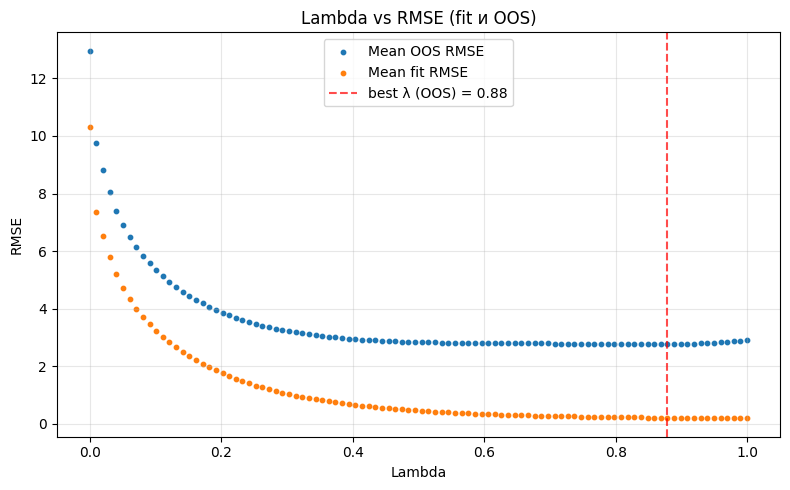

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(summary_df["lambda"], summary_df["mean_oos_rmse"], s=10, label="Mean OOS RMSE", color="tab:blue")
plt.scatter(summary_df["lambda"], summary_df["mean_fit_rmse"], s=10, label="Mean fit RMSE", color="tab:orange")
plt.axvline(best_lambda, color="red", linestyle="--", alpha=0.7, label=f"best λ (OOS) = {best_lambda:.2f}")
plt.xlabel("Lambda")
plt.ylabel("RMSE")
plt.title("Lambda vs RMSE (fit и OOS)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()